In [1]:

import yfinance as yf
import datetime as dt

start = dt.datetime(2024,1,1)
end = dt.datetime(2025,1,1)
# stk_data = yf.download('SBIN.NS', start, end, multi_level_index=False, progress=False)
# stk_data.to_csv('SBIN_data.csv')


In [2]:
from data_analysis_utils import Univariate as univ, Preprocessing as prep, NormalDistribution as norm
import pandas as pd
stk_data = pd.read_csv('SBIN_data.csv', parse_dates=True)

print(stk_data.info())
stk_data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    246 non-null    object 
 1   Close   246 non-null    float64
 2   High    246 non-null    float64
 3   Low     246 non-null    float64
 4   Open    246 non-null    float64
 5   Volume  246 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 11.7+ KB
None


,Date,Close,High,Low,Open,Volume
0,2024-01-01,618.355835,623.706899,615.125965,619.175395,8295548
1,2024-01-02,616.523987,624.767434,611.124727,618.355831,15164482
2,2024-01-03,620.380554,624.767412,613.004804,616.427515,14571772
3,2024-01-04,619.705627,623.224788,615.752647,619.464591,13883388
4,2024-01-05,618.934387,628.383019,614.884957,621.875025,15984585
...,...,...,...,...,...,...
241,2024-12-24,796.065369,809.936860,793.271493,808.025232,10602771
242,2024-12-26,796.457520,806.652767,792.095103,796.996681,8318714
243,2024-12-27,783.909485,802.192337,781.507699,800.231706,10649800
244,2024-12-30,772.782837,792.046064,769.547807,786.213174,21515438


In [3]:
dataset=stk_data
quan,qual=prep.quanQual(dataset)
print('Quantitative',quan,'\nQualitative',qual)

low=stk_data["Low"]


Quantitative Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object') 
Qualitative Index(['Date'], dtype='object')


In [4]:
des_data=univ.descriptive(dataset,quan)
des_data


,Close,High,Low,Open,Volume
Mean,770.07,778.78,761.67,770.67,17569587.93
Mode,786.066101,600.036987,579.115049,588.081597,1637141
Min,583.405457,600.036987,579.115049,588.081597,1637141
Q1-25th%,738.681381,744.996581,729.517744,738.476536,11374262.75
Median / Q2-50%,787.619629,797.878959,780.15975,788.418875,14761738.5
Q3-75th%,816.308899,825.241976,807.829144,817.313652,20031429.75
99th%,868.31,878.46,854.75,865.31,69743397.7
Max-100th%,887.822937,894.047918,865.912852,879.343174,122381193
IQR,77.627518,80.245395,78.3114,78.837116,8657167.0
1.5rule,116.441277,120.368092,117.467099,118.255674,12985750.5


Mean: 761.67 
STD: 67.67 
Probability%: 19.09


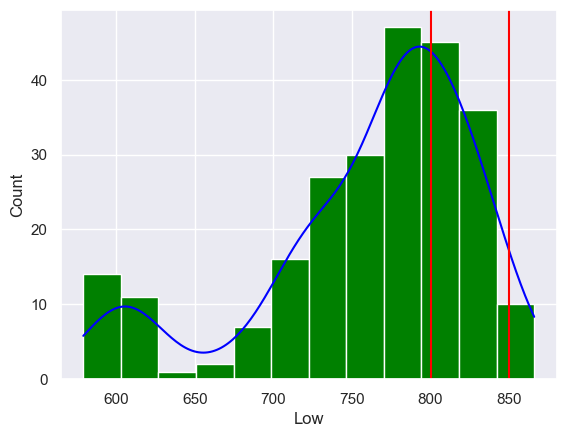

In [5]:

mean, std, prob= norm.get_pdf_probability(dataset["Low"],800,850)
print('Mean:',mean.round(2), '\nSTD:', std.round(2), '\nProbability%:', (prob*100).round(2))


Average z-score: 1.7544682960285757e-16 
Standard Deviation for z-score: 1.0


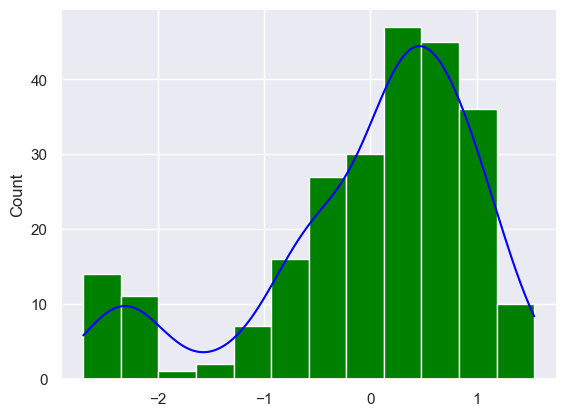

In [9]:
avg_z, std_z = norm.stdNBgraph(dataset["Low"])
print('Average z-score:', avg_z, '\nStandard Deviation for z-score:', std_z)


In [20]:
fh = univ.freqTable(dataset, 'Close')
fh


,UniqueValues,Frequency,RelativeFrequency%,Cumsum%
0,842.777405,2,0.81,0.81
1,787.193481,2,0.81,1.62
2,786.066101,2,0.81,2.43
3,804.152954,2,0.81,3.24
4,816.308899,2,0.81,4.05
...,...,...,...,...
234,773.149658,1,0.41,99.15
235,781.730530,1,0.41,99.56
236,790.407898,1,0.41,99.97
237,788.045776,1,0.41,100.38


In [21]:
fh.sort_values(by="Frequency",ascending=False)


,UniqueValues,Frequency,RelativeFrequency%,Cumsum%
0,842.777405,2,0.81,0.81
2,786.066101,2,0.81,2.43
3,804.152954,2,0.81,3.24
4,816.308899,2,0.81,4.05
5,802.633484,2,0.81,4.86
...,...,...,...,...
87,783.909485,1,0.41,38.88
88,772.782837,1,0.41,39.29
89,798.271057,1,0.41,39.70
90,810.427002,1,0.41,40.11


In [22]:
fhs=fh[fh["Frequency"]==2]["UniqueValues"].sort_values(ascending=False)
fhs


0    842.777405
4    816.308899
3    804.152954
5    802.633484
6    792.732300
1    787.193481
2    786.066101
Name: UniqueValues, dtype: float64